# Examen final - Primer punto

En este punto utilizo OpenCV con la imagen del un Manatí (un animal en peligro de extinción) para aplicar varios filtros y operaciones morfológicas, y finalmente generar un GIF que muestre los resultados. La imagen del manatí tiene una piel arrugada en la naríz y un fondo difuso lo cual permite observar los efectos de los filtros y operaciones morfológicas aplicadas. También al ser una imagen submarina con vegetación, permite observar los efectos de la separación de canales de color.

In [ ]:
!sudo apt-get update && sudo apt-get install -y libgl1 libglib2.0-0
!pip install opencv-python matplotlib numpy imageio

## Importe de librerías necesarias

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### 1. **Carga y visualización de una imagen (RGB) de un animal en via de extinción:**
   - Carga una imagen a color (RGB) desde archivo.
   - Muestra la imagen original en una figura.

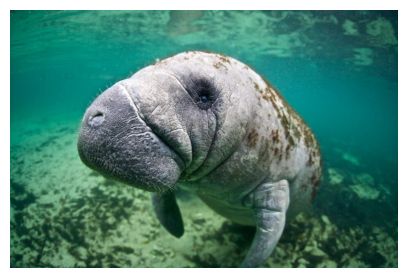

In [8]:
img_path = "data/animal_extincion.jpg"  
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5,5))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

### 2. **Filtros básicos:**
   Aplica los siguientes filtros a la imagen :
   - Suavizado / desenfoque 
   - Realce de bordes 

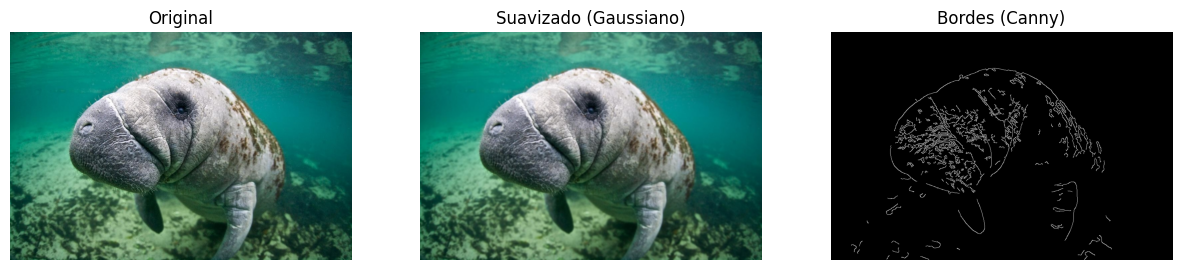

In [15]:
# Suavizado Gaussiano
desfonque = cv2.GaussianBlur(img_rgb, (5, 5), 0)

# Detección de bordes
img_gray = cv2.cvtColor(desfonque, cv2.COLOR_RGB2GRAY)
bordes = cv2.Canny(img_gray, 100, 200)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(img_rgb); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(desfonque); plt.title("Suavizado (Gaussiano)"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(bordes, cmap="gray"); plt.title("Bordes (Canny)"); plt.axis("off")
plt.show()

Podemos observar del filtro gaussiano que el desenfoque es efectivo para reducir el ruido en la imagen, pero también puede suavizar detalles importantes. 
De hecho, he utilizado el utilizado el tamaño de kernel (5,5) para un desenfoque moderaddo y esta imagen desenfocada es que se utiliza para la detección de bordes con el algoritmo Canny.

### 3. **Visualización de canales de color:**
   - Separa la imagen original en sus tres canales (R, G, B).
   - Muestra en una figura:
     - Los tres canales en escala de grises (cada canal por separado).
   - Explica brevemente qué estructuras se ven más claras u oscuras en cada canal y por qué.

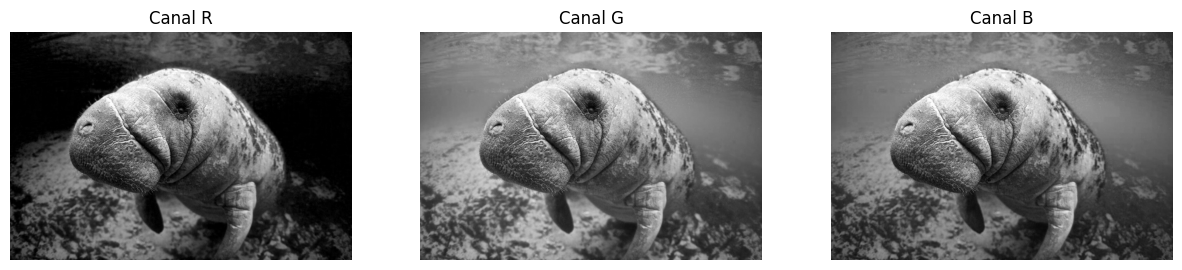

In [16]:
R, G, B = cv2.split(img_rgb)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(R, cmap="gray"); plt.title("Canal R"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(G, cmap="gray"); plt.title("Canal G"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(B, cmap="gray"); plt.title("Canal B"); plt.axis("off")
plt.show()

Podemos notar que el canal rojo es mayormente oscuro debido a que la imágen del manatí debajo del agua tiene predominancia de colores verdes y azules, mientras que el canal azul y verden son mas claros ya que hay muucha vegetación submarina además del agua misma.

### 4. **Operaciones morfológicas :**
   - Trabaja sobre una versión en escala de grises o binarizada de la imagen.
   - Aplica dos operaciones morfológicas diferentes

   - Muestra los resultados comparando:
     - Imagen original (o binarizada).
     - Imagen después de cada operación.
   - Explica brevemente que efecto tuvo la operación sobre la imagen

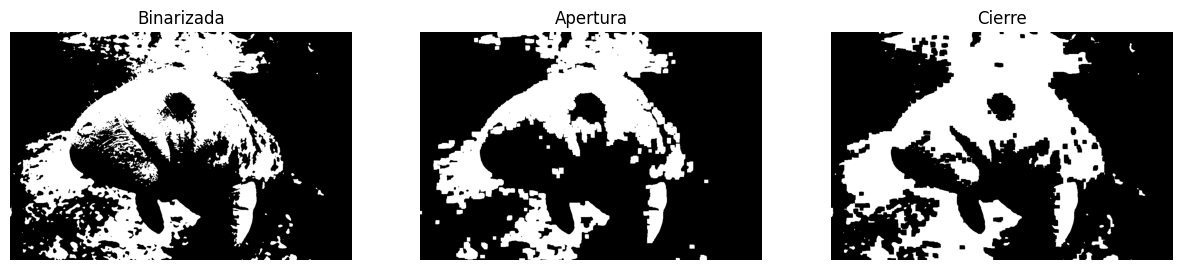

In [ ]:
threshold, binary = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print("Umbral óptimo (Otsu):", threshold)

kernel_size = 10
kernel = np.ones((kernel_size, kernel_size), np.uint8)

opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(binary, cmap="gray"); plt.title("Binarizada"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(opening, cmap="gray"); plt.title("Apertura"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(closing, cmap="gray"); plt.title("Cierre"); plt.axis("off")
plt.show()

La función `cv2.threshold()` con `cv2.THRESH_OTSU` calcula automáticamente el valor óptimo de umbral (threshold) para binarizar la imagen en escala de grises. Esto separa la imagen en píxeles blancos (255) y negros (0) basándose en el histograma de intensidades.

https://en.wikipedia.org/wiki/Otsu%27s_method

El tamaño del kernel (10x10) determina qué tan agresivas son estas operaciones

Luego se aplican dos opetaciones morfológicas `cv2.morphologyEx()`:

1. **Apertura (Opening)**: Esta operación consiste en una erosión seguida de una dilatación. Elimina pequeños objetos y ruido blanco de la imagen, además de separar objetos conectados por regiones delgadas. 

2. **Cierre (Closing)**: Esta operación consiste en una dilatación seguida de una erosión. Rellena pequeños agujeros negros en objetos blancos y conecta regiones cercanas.



### 5. **Animación:**
   - Genera una animación simple  o creando un GIF a partir de varios frames donde se vea:
     - La imagen original.
     - Los resultados de los filtros y/o operaciones morfológicas de forma secuencial.

![punto1](gifs/punto1.gif)

In [25]:
import imageio 
from pathlib import Path

edges_rgb = cv2.cvtColor(bordes, cv2.COLOR_GRAY2RGB)
binary_rgb = cv2.cvtColor(binary, cv2.COLOR_GRAY2RGB)
opening_rgb = cv2.cvtColor(opening, cv2.COLOR_GRAY2RGB)
closing_rgb = cv2.cvtColor(closing, cv2.COLOR_GRAY2RGB)

frames = [
    img_rgb,
    desfonque,
    edges_rgb,
    binary_rgb,
    opening_rgb,
    closing_rgb
]

out_path = Path("gifs")
out_path.mkdir(parents=True, exist_ok=True)
gif_file = out_path / "punto1.gif"

imageio.mimsave(gif_file, frames, duration=5, loop=0, fps=1)

print("GIF guardado en:", gif_file)

GIF guardado en: gifs/punto1.gif
